In [1]:
import librosa
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

In [2]:
DATA_DIR = Path('../data/1st_test')
files = sorted([f for f in DATA_DIR.iterdir() if f.is_file() and not f.name.startswith('.')])

In [3]:
cols = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8"]

def read_single(file):
    df = pd.read_csv(file, sep='\t', header=None, names=cols)
    return df

(64, 32) max:  9.856296511266375 min:  -24.066738295542223
(64, 32) max:  10.993733302501248 min:  -21.55067563827989


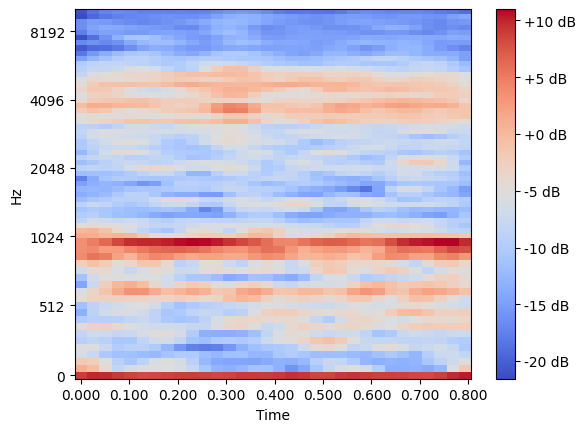

In [4]:
healthy = read_single(files[1])
healthy_B1 = np.array(healthy["B1"].values)
degraded = read_single(files[-1])
degraded_B1 = np.array(degraded["B1"].values)
# Create mel spectrogram from the given signal
def create_spectrogram(signal):
    mel_spec = librosa.feature.melspectrogram(y = signal, sr = 20000, n_fft=1024, n_mels=64, hop_length=128)
    mel_spec = librosa.power_to_db(mel_spec, ref=1.0)
    return mel_spec
spectrogram1 = create_spectrogram(healthy_B1[:4095])
spectrogram2 = create_spectrogram(degraded_B1[:4095])
librosa.display.specshow(spectrogram1, sr = 20000,  x_axis='time', y_axis = 'mel')
print(spectrogram1.shape, "max: ",spectrogram1.max(), "min: ",spectrogram1.min())
librosa.display.specshow(spectrogram2, sr = 20000,  x_axis='time', y_axis = 'mel')
print(spectrogram2.shape, "max: ",spectrogram2.max(), "min: ",spectrogram2.min())
plt.colorbar(format='%+2.0f dB')

In [ ]:
from tqdm import tqdm

WINDOW_SIZE = 4096
HOP_SIZE = WINDOW_SIZE // 2

cutoff = int(len(files) * 0.8)
train_set = files[:cutoff]
test_set = files[cutoff:]


def generate_dataset(file_list):
    dataset = []
    for file in tqdm(file_list):
        df = read_single(file)

        num_windows = (len(df) - WINDOW_SIZE) // HOP_SIZE + 1

        signals = df['B7'].values
        
        for i in range(num_windows):
            start = i * HOP_SIZE
            end = start + WINDOW_SIZE
            mel_spectrogram = create_spectrogram(signals[start:end])
            dataset.append(mel_spectrogram)

    spectograms_dataset = np.stack(dataset)
    return spectograms_dataset

training = generate_dataset(train_set)
testing = generate_dataset(test_set)
print("Training- Shape: {}, min: {}, MAX: {}".format(training.shape, training.min(), training.max()))
print("Testing- Shape: {}, min: {}, MAX: {}".format(testing.shape, testing.min(), testing.max()))

100%|██████████| 432/432 [00:15<00:00, 27.14it/s]

Training- Shape: (15516, 64, 33), min: -35.838186448524155, MAX: 16.181272678717665
Testing- Shape: (3888, 64, 33), min: -30.846761529084578, MAX: 12.991937592889379


In [6]:
# Save dataset
output_dir = Path('../datasets')
output_dir.mkdir(parents=True, exist_ok=True)
np.save(output_dir/'training_set.npy', training)
np.save(output_dir/'testing_set', testing)